# 05 — Feature extraction and latent representations

I fit PCA first as a linear baseline, then UMAP and ISOMAP on PCA-reduced V1 population activity. I use these embeddings as baseline manifolds before CEBRA and downstream decoding.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from v1_manifold.config import load_config, get_paths, set_global_seed
from v1_manifold.visualization import set_publication_style, save_figure
from v1_manifold.utils import save_table

cfg = load_config(ROOT / "configs" / "default.yaml")
cfg["paths"]["root"] = str(ROOT)
paths = get_paths(cfg)
set_global_seed(cfg["project"]["random_seed"])
set_publication_style()

print(f"Project root: {ROOT}")


Project root: c:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies


## Load the processed neural tensor and real movie-frame features

I use the repeat-averaged population response matrix from notebook 03. Each row corresponds to one natural movie frame and each column corresponds to one retained V1 neuron.

I also load the real frame-feature table created in notebook 04. The analysis stops if fallback stimulus labels are present, because latent-feature interpretation should use real visual features extracted from the Allen natural movie pixels.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from v1_manifold.preprocessing import load_trial_tensor_h5
from v1_manifold.features import standardize_matrix, assert_real_stimulus_features
from v1_manifold.manifold import fit_pca, fit_umap, fit_isomap, save_embedding_npz, save_model

h5_files = sorted(paths.interim_dir.glob("session_*_tensor.h5"))
if not h5_files:
    raise FileNotFoundError("No trial tensor exists yet. I need to run notebook 03 first.")

tensor_path = h5_files[0]
session_id = tensor_path.name.split("_")[1]

tensor, R = load_trial_tensor_h5(tensor_path)

real_feature_candidates = sorted(paths.processed_dir.glob(f"session_{session_id}*_real_frame_features.csv"))
generic_feature_candidates = sorted(paths.processed_dir.glob(f"session_{session_id}*_frame_features.csv"))

if real_feature_candidates:
    feature_path = real_feature_candidates[0]
elif generic_feature_candidates:
    feature_path = generic_feature_candidates[0]
else:
    raise FileNotFoundError("Real frame features are missing. I need to run notebook 04 first.")

features = pd.read_csv(feature_path)
features = features.sort_values("movie_frame").reset_index(drop=True)

assert_real_stimulus_features(features)

if R.shape[0] != len(features):
    raise ValueError(
        "The neural response matrix and feature table do not align: "
        f"R has {R.shape[0]} frames but features has {len(features)} rows."
    )

expected_frames = np.arange(R.shape[0])
if not np.array_equal(features["movie_frame"].to_numpy(), expected_frames):
    raise ValueError(
        "The feature table movie_frame column is not aligned to the neural matrix rows. "
        "I expected frames 0..n_frames-1 after sorting."
    )

Xz, scaler = standardize_matrix(R)
save_model(scaler, paths.models_dir / f"session_{session_id}_scaler.joblib")

print("Tensor shape:", tensor.shape)
print("Repeat-averaged matrix shape:", R.shape)
print("Feature table:", feature_path)
print("Feature columns:", len(features.columns))
display(features.head())


Tensor shape: (10, 163, 900)
Repeat-averaged matrix shape: (900, 163)
Feature table: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500855614_natural_movie_one_real_frame_features.csv
Feature columns: 34


,movie_frame,population_mean,population_std,population_l2_norm,n_cells,luminance_mean,luminance_std,rms_contrast,dominant_orientation_bin,dominant_orientation_angle_rad,...,spatial_frequency_energy_bin_1,spatial_frequency_energy_bin_2,spatial_frequency_energy_bin_3,spatial_frequency_energy_bin_4,dominant_orientation_coarse,dominant_orientation_coarse_is_other,orientation_confidence,orientation_confidence_threshold,dominant_orientation_confident,dominant_orientation_confident_is_ambiguous
0,0,0.459886,2.380123,30.949413,163,0.490070,0.173897,0.354841,4,1.767146,...,0.588674,0.237981,0.036750,0.001043,bin_4,False,0.347660,0.351332,ambiguous,True
1,1,0.475428,2.378806,30.971182,163,0.489777,0.172505,0.352212,4,1.767146,...,0.584581,0.238913,0.038509,0.000953,bin_4,False,0.346613,0.351332,ambiguous,True
2,2,0.436005,2.304510,29.943974,163,0.489762,0.172541,0.352296,4,1.767146,...,0.583764,0.239259,0.038441,0.000957,bin_4,False,0.346748,0.351332,ambiguous,True
3,3,0.373745,2.170050,28.113255,163,0.489371,0.171676,0.350809,4,1.767146,...,0.575348,0.243556,0.040149,0.000976,bin_4,False,0.339802,0.351332,ambiguous,True
4,4,0.420181,2.040942,26.603487,163,0.489342,0.171249,0.349959,4,1.767146,...,0.567800,0.251179,0.044694,0.000945,bin_4,False,0.334459,0.351332,ambiguous,True


## Fit PCA, UMAP, and ISOMAP embeddings

I fit PCA as the linear baseline and compute the participation ratio as an effective dimensionality estimate. UMAP and ISOMAP are then fit on PCA scores so that nonlinear embedding is not dominated by raw high-dimensional noise.


In [3]:
pca_components = min(
    int(cfg["features"]["pca_components"]),
    Xz.shape[0],
    Xz.shape[1],
)

pca_scores, pca, pr = fit_pca(
    Xz,
    pca_components,
    cfg["project"]["random_seed"],
)

save_model(pca, paths.models_dir / f"session_{session_id}_pca.joblib")

embedding_dim = 3

pca_embedding = pca_scores[:, :embedding_dim]

umap_embedding = fit_umap(
    pca_scores,
    embedding_dim,
    cfg["features"]["umap_neighbors"],
    cfg["features"]["umap_min_dist"],
    cfg["project"]["random_seed"],
)

isomap_embedding = fit_isomap(
    pca_scores,
    embedding_dim,
    cfg["features"]["isomap_neighbors"],
)

emb_path = paths.processed_dir / f"session_{session_id}_embeddings.npz"

save_embedding_npz(
    emb_path,
    pca=pca_embedding,
    pca_full=pca_scores,
    umap=umap_embedding,
    isomap=isomap_embedding,
    frame=features["movie_frame"].to_numpy(),
    rms_contrast=features["rms_contrast"].to_numpy() if "rms_contrast" in features.columns else np.full(R.shape[0], np.nan),
    spatial_frequency_centroid=features["spatial_frequency_centroid"].to_numpy() if "spatial_frequency_centroid" in features.columns else np.full(R.shape[0], np.nan),
)

print(f"Participation ratio: {pr:.3f}")
print("Saved embeddings:", emb_path)


c:\Users\Peter\.neuro\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Participation ratio: 16.302
Saved embeddings: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500855614_embeddings.npz


## PCA spectrum

The participation ratio summarizes how many principal directions effectively contribute to the population response. I use it as a simple dimensionality baseline before interpreting nonlinear latent geometry.


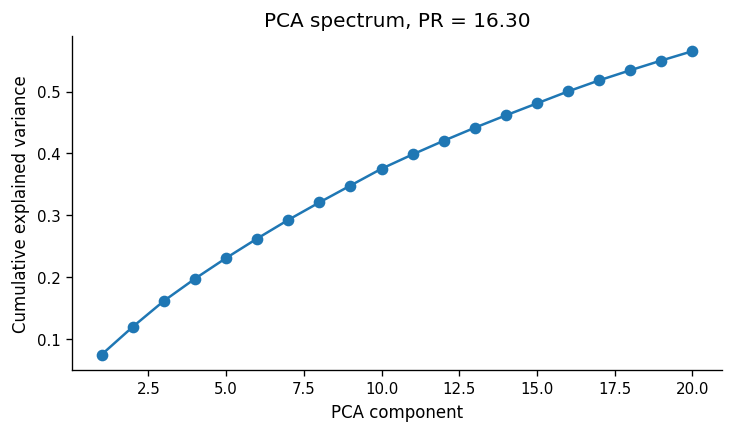

In [4]:
explained = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
})

save_table(
    explained,
    paths.tables_dir / f"05_pca_explained_variance_session_{session_id}.csv",
)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(
    explained["component"],
    explained["cumulative_explained_variance"],
    marker="o",
)
ax.set_xlabel("PCA component")
ax.set_ylabel("Cumulative explained variance")
ax.set_title(f"PCA spectrum, PR = {pr:.2f}")

save_figure(
    fig,
    paths.figures_dir / "05_pca_cumulative_explained_variance.png",
)

plt.show()


## Visualize embeddings with correctly labelled colorbars

I color each embedding by movie frame index and by real stimulus features. The colorbar label is explicitly tied to the plotted variable so contrast and spatial-frequency plots are not mislabeled as movie-frame plots.


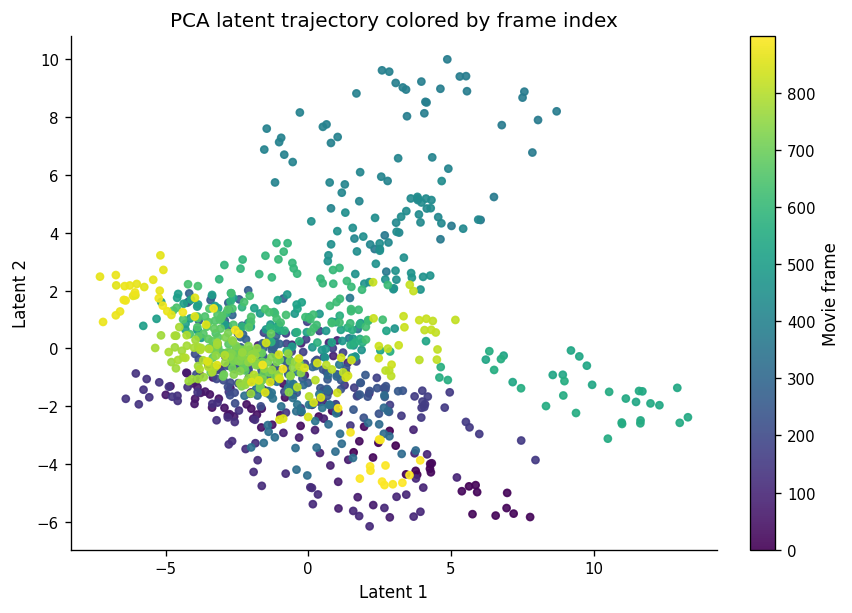

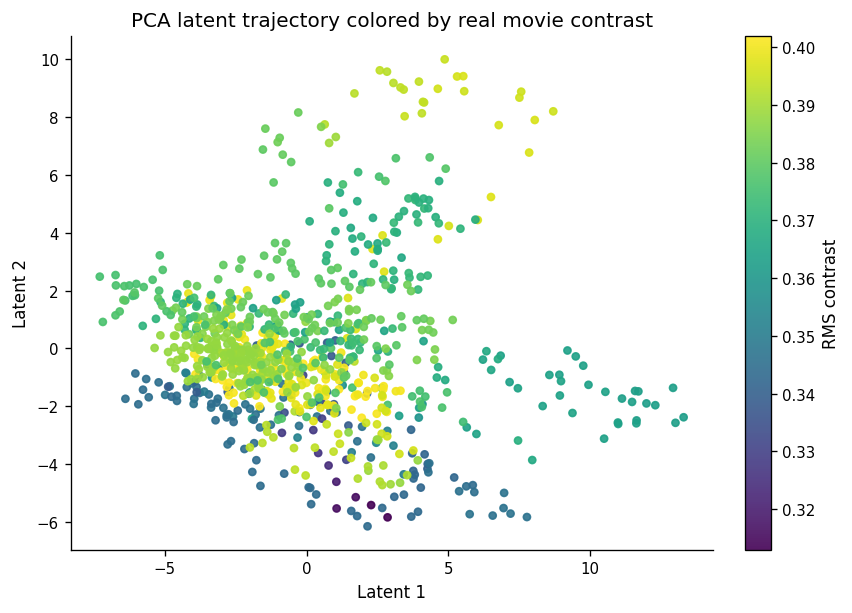

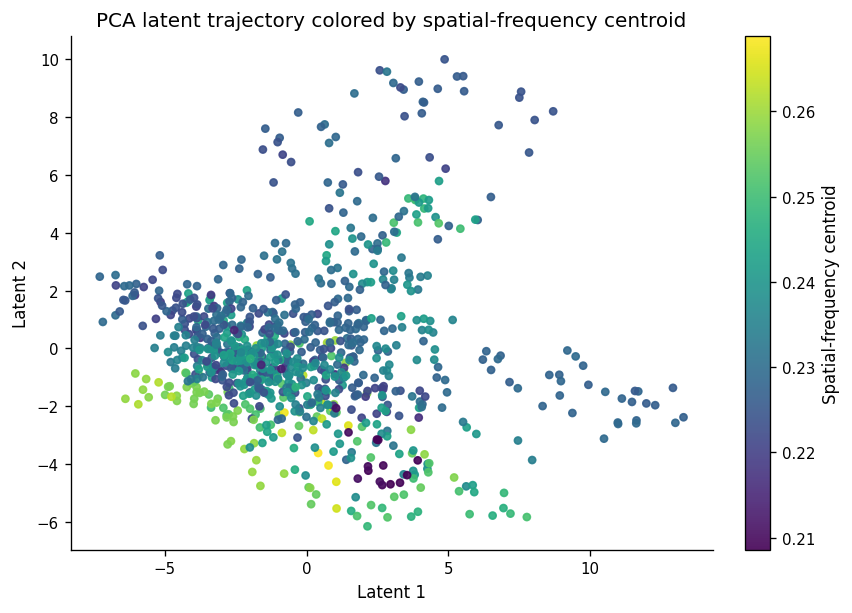

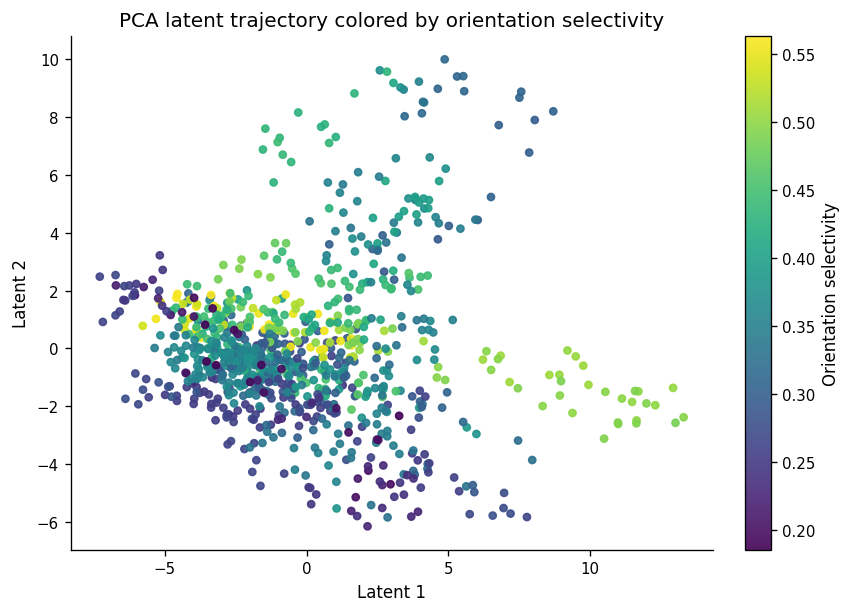

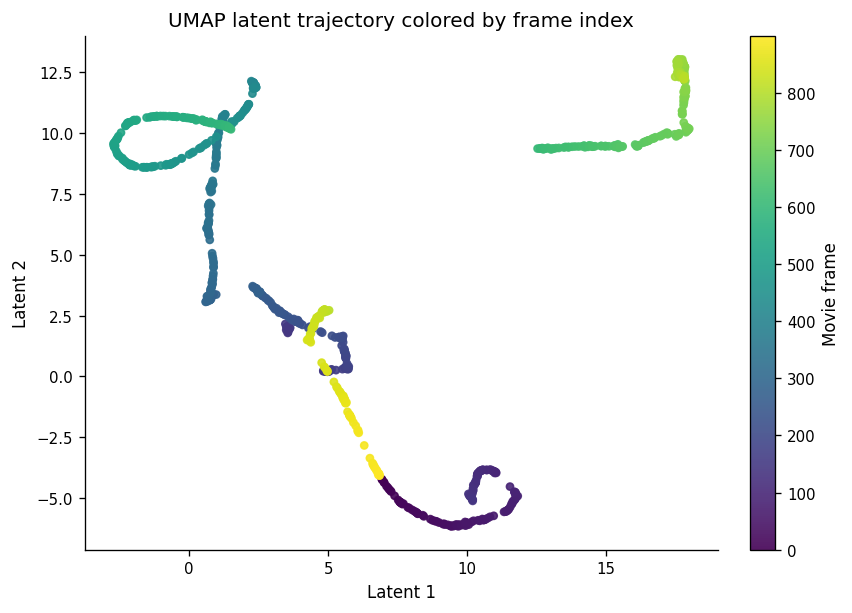

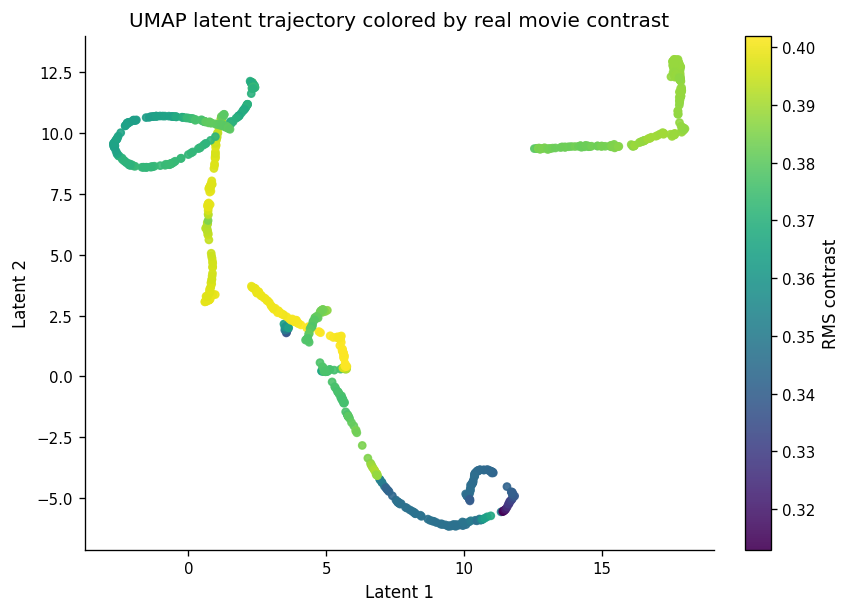

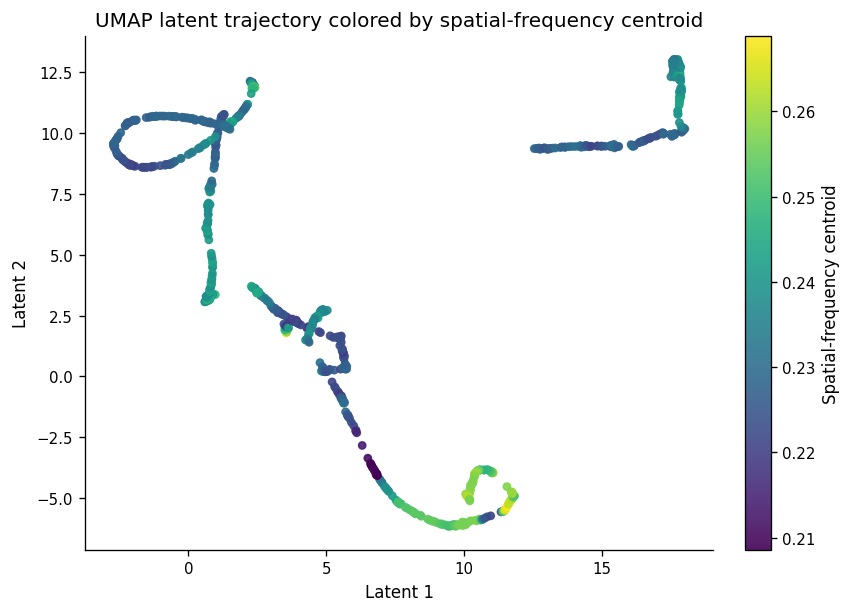

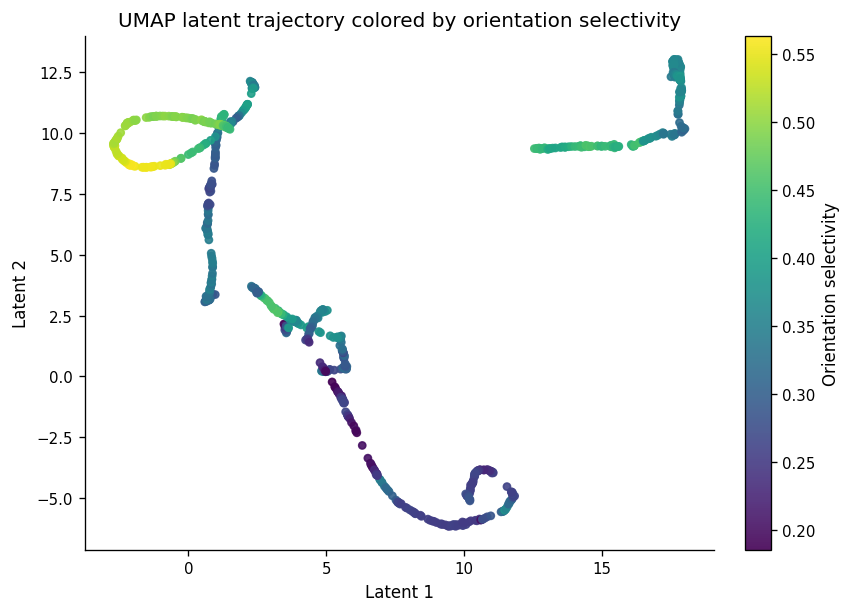

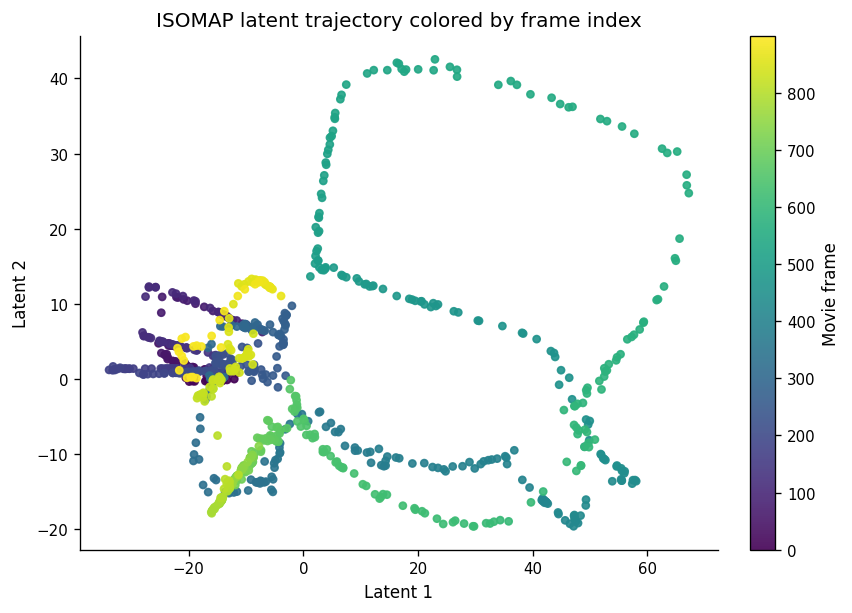

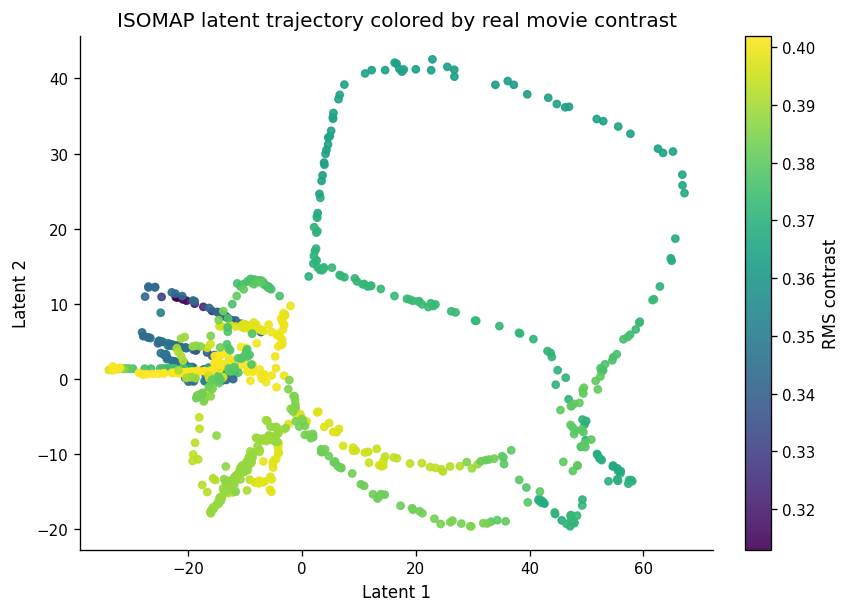

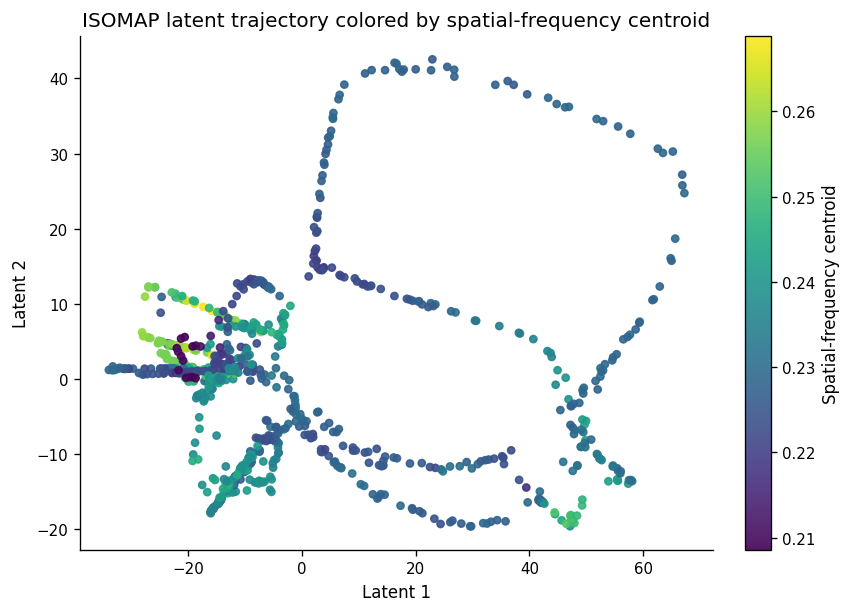

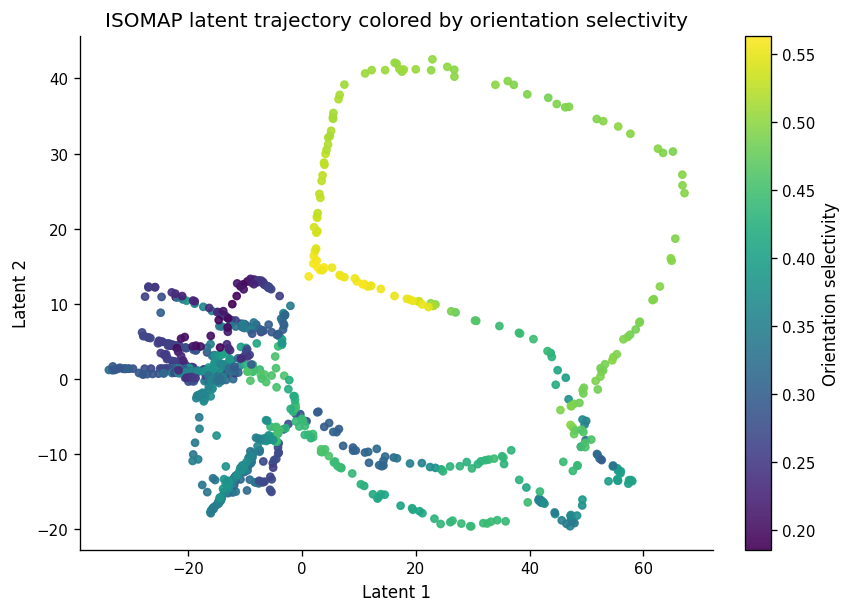

In [5]:
def plot_embedding_colored(
    embedding,
    color_values,
    title,
    colorbar_label,
    save_path,
    point_size=18,
    alpha=0.90,
):
    """Plot a 2D embedding with a correctly labelled continuous colorbar."""
    embedding = np.asarray(embedding)
    color_values = np.asarray(color_values)

    if embedding.ndim != 2 or embedding.shape[1] < 2:
        raise ValueError("I need an embedding matrix with at least two latent dimensions.")

    if embedding.shape[0] != color_values.shape[0]:
        raise ValueError(
            f"Embedding has {embedding.shape[0]} rows but color vector has {color_values.shape[0]} values."
        )

    fig, ax = plt.subplots(figsize=(7, 5))

    sc = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=color_values,
        s=point_size,
        alpha=alpha,
    )

    ax.set_xlabel("Latent 1")
    ax.set_ylabel("Latent 2")
    ax.set_title(title)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(colorbar_label)

    save_figure(fig, save_path)
    plt.show()

    return fig


embedding_dict = {
    "pca": pca_embedding,
    "umap": umap_embedding,
    "isomap": isomap_embedding,
}

color_specs = [
    {
        "column": "movie_frame",
        "values": features["movie_frame"].to_numpy(),
        "label": "Movie frame",
        "slug": "frame_index",
        "title_suffix": "frame index",
    },
    {
        "column": "rms_contrast",
        "values": features["rms_contrast"].to_numpy(),
        "label": "RMS contrast",
        "slug": "rms_contrast",
        "title_suffix": "real movie contrast",
    },
    {
        "column": "spatial_frequency_centroid",
        "values": features["spatial_frequency_centroid"].to_numpy(),
        "label": "Spatial-frequency centroid",
        "slug": "spatial_frequency",
        "title_suffix": "spatial-frequency centroid",
    },
]

if "orientation_selectivity" in features.columns:
    color_specs.append({
        "column": "orientation_selectivity",
        "values": features["orientation_selectivity"].to_numpy(),
        "label": "Orientation selectivity",
        "slug": "orientation_selectivity",
        "title_suffix": "orientation selectivity",
    })

for name, Z in embedding_dict.items():
    for spec in color_specs:
        plot_embedding_colored(
            embedding=Z,
            color_values=spec["values"],
            title=f"{name.upper()} latent trajectory colored by {spec['title_suffix']}",
            colorbar_label=spec["label"],
            save_path=paths.figures_dir / f"05_{name}_latent_trajectory_{spec['slug']}.png",
        )


## Quantify whether latent coordinates predict real movie features

The scatter plots are useful but not enough. I quantify whether each embedding predicts real continuous movie-frame features using block-wise cross-validation over contiguous movie segments.

This is stricter than random frame-wise cross-validation because adjacent natural movie frames are highly autocorrelated.


In [6]:
from v1_manifold.evaluation import (
    make_contiguous_frame_blocks,
    frame_time_features,
    evaluate_feature_regression,
)

continuous_targets = [
    "rms_contrast",
    "spatial_frequency_centroid",
    "orientation_selectivity",
    "luminance_std",
    "total_spectral_power",
]

continuous_targets = [target for target in continuous_targets if target in features.columns]

frame_blocks = make_contiguous_frame_blocks(
    n_samples=len(features),
    n_blocks=int(cfg.get("evaluation", {}).get("n_movie_blocks", 5)),
)

latent_representations = {
    "pca_3d": pca_embedding,
    "pca_20d": pca_scores[:, :min(20, pca_scores.shape[1])],
    "umap_3d": umap_embedding,
    "isomap_3d": isomap_embedding,
}

latent_feature_scores = evaluate_feature_regression(
    latent_representations,
    features,
    continuous_targets,
    groups=frame_blocks,
    alpha=float(cfg.get("evaluation", {}).get("latent_regression_alpha", 1.0)),
)

save_table(
    latent_feature_scores,
    paths.tables_dir / "05_latent_embedding_real_feature_regression.csv",
)

display(
    latent_feature_scores.sort_values(
        ["target", "mean_r2"],
        ascending=[True, False],
    )
)


,representation,target,cv_strategy,n_samples,n_features,mean_r2,std_r2,mean_mae,std_mae,mean_rmse,std_rmse,mean_spearman_r,std_spearman_r
13,umap_3d,luminance_std,contiguous_movie_block_groupkfold,900,3,-19.235212,31.861634,0.011061,0.008300,0.012265,0.008110,0.028167,0.489797
8,pca_20d,luminance_std,contiguous_movie_block_groupkfold,900,20,-25.342551,47.686516,0.011372,0.009341,0.012946,0.009600,0.244048,0.228077
3,pca_3d,luminance_std,contiguous_movie_block_groupkfold,900,3,-25.982723,47.822738,0.012506,0.009316,0.013253,0.009572,0.049576,0.311137
18,isomap_3d,luminance_std,contiguous_movie_block_groupkfold,900,3,-26.867689,54.135983,0.010624,0.010518,0.011390,0.010557,0.283326,0.635633
12,umap_3d,orientation_selectivity,contiguous_movie_block_groupkfold,900,3,-0.196487,0.310576,0.051744,0.014518,0.062920,0.013205,0.475925,0.250887
17,isomap_3d,orientation_selectivity,contiguous_movie_block_groupkfold,900,3,-0.815752,0.714639,0.065875,0.033924,0.079779,0.036484,-0.009933,0.537165
2,pca_3d,orientation_selectivity,contiguous_movie_block_groupkfold,900,3,-0.894758,0.638017,0.067033,0.026288,0.080187,0.027160,0.050894,0.544475
7,pca_20d,orientation_selectivity,contiguous_movie_block_groupkfold,900,20,-5.241166,6.075104,0.103871,0.022699,0.121515,0.023314,0.034266,0.334883
10,umap_3d,rms_contrast,contiguous_movie_block_groupkfold,900,3,-19.888531,32.734376,0.020598,0.015434,0.022831,0.015146,0.014557,0.510175
5,pca_20d,rms_contrast,contiguous_movie_block_groupkfold,900,20,-25.837035,48.724766,0.021003,0.017277,0.023928,0.017782,0.251611,0.220034


## Compare embeddings with temporal and scalar neural baselines

A structured latent trajectory can arise because the natural movie itself is temporally continuous. I therefore compare PCA, UMAP, and ISOMAP against frame-index baselines and a scalar population-energy baseline.

This does not prove causality, but it prevents me from overinterpreting a visually smooth manifold as stimulus-feature coding without a quantitative control.


In [7]:
baseline_representations = {
    "frame_index_linear_baseline": features["movie_frame"].to_numpy().reshape(-1, 1),
    "frame_index_fourier_baseline": frame_time_features(
        features["movie_frame"].to_numpy(),
        n_harmonics=int(cfg.get("evaluation", {}).get("temporal_fourier_harmonics", 5)),
    ),
    "population_l2_norm_baseline": features["population_l2_norm"].to_numpy().reshape(-1, 1),
}

baseline_scores = evaluate_feature_regression(
    baseline_representations,
    features,
    continuous_targets,
    groups=frame_blocks,
    alpha=float(cfg.get("evaluation", {}).get("latent_regression_alpha", 1.0)),
)

save_table(
    baseline_scores,
    paths.tables_dir / "05_frame_index_and_population_energy_baselines.csv",
)

latent_vs_baseline = pd.concat(
    [latent_feature_scores, baseline_scores],
    ignore_index=True,
)

save_table(
    latent_vs_baseline,
    paths.tables_dir / "05_latent_vs_time_feature_prediction.csv",
)

display(
    latent_vs_baseline.sort_values(
        ["target", "mean_r2"],
        ascending=[True, False],
    )
)


,representation,target,cv_strategy,n_samples,n_features,mean_r2,std_r2,mean_mae,std_mae,mean_rmse,std_rmse,mean_spearman_r,std_spearman_r
13,umap_3d,luminance_std,contiguous_movie_block_groupkfold,900,3,-19.235212,31.861634,0.011061,0.008300,0.012265,0.008110,0.028167,0.489797
33,population_l2_norm_baseline,luminance_std,contiguous_movie_block_groupkfold,900,1,-20.154449,40.335634,0.009591,0.007004,0.010294,0.007141,0.115737,0.390661
8,pca_20d,luminance_std,contiguous_movie_block_groupkfold,900,20,-25.342551,47.686516,0.011372,0.009341,0.012946,0.009600,0.244048,0.228077
3,pca_3d,luminance_std,contiguous_movie_block_groupkfold,900,3,-25.982723,47.822738,0.012506,0.009316,0.013253,0.009572,0.049576,0.311137
18,isomap_3d,luminance_std,contiguous_movie_block_groupkfold,900,3,-26.867689,54.135983,0.010624,0.010518,0.011390,0.010557,0.283326,0.635633
23,frame_index_linear_baseline,luminance_std,contiguous_movie_block_groupkfold,900,1,-36.925176,75.171966,0.011571,0.010039,0.012481,0.009924,-0.279670,0.744231
28,frame_index_fourier_baseline,luminance_std,contiguous_movie_block_groupkfold,900,11,-92.520919,163.934559,0.018985,0.009531,0.021281,0.010250,0.054898,0.306358
12,umap_3d,orientation_selectivity,contiguous_movie_block_groupkfold,900,3,-0.196487,0.310576,0.051744,0.014518,0.062920,0.013205,0.475925,0.250887
17,isomap_3d,orientation_selectivity,contiguous_movie_block_groupkfold,900,3,-0.815752,0.714639,0.065875,0.033924,0.079779,0.036484,-0.009933,0.537165
2,pca_3d,orientation_selectivity,contiguous_movie_block_groupkfold,900,3,-0.894758,0.638017,0.067033,0.026288,0.080187,0.027160,0.050894,0.544475


## Summarize whether neural embeddings add information beyond time

For each real movie feature, I compare the best latent embedding against the best frame-index baseline. A positive delta means the neural embedding predicts that feature better than the temporal baseline under the same block-wise split.


In [8]:
is_temporal_baseline = latent_vs_baseline["representation"].isin([
    "frame_index_linear_baseline",
    "frame_index_fourier_baseline",
])

best_temporal = (
    latent_vs_baseline[is_temporal_baseline]
    .sort_values(["target", "mean_r2"], ascending=[True, False])
    .groupby("target", as_index=False)
    .first()
    .rename(columns={
        "representation": "best_temporal_baseline",
        "mean_r2": "best_temporal_mean_r2",
        "mean_mae": "best_temporal_mean_mae",
        "mean_spearman_r": "best_temporal_mean_spearman_r",
    })
)

best_latent = (
    latent_vs_baseline[~is_temporal_baseline]
    .query("representation != 'population_l2_norm_baseline'")
    .sort_values(["target", "mean_r2"], ascending=[True, False])
    .groupby("target", as_index=False)
    .first()
    .rename(columns={
        "representation": "best_latent_representation",
        "mean_r2": "best_latent_mean_r2",
        "mean_mae": "best_latent_mean_mae",
        "mean_spearman_r": "best_latent_mean_spearman_r",
    })
)

latent_gain = best_latent.merge(
    best_temporal,
    on="target",
    how="left",
)

latent_gain["delta_r2_vs_best_temporal"] = (
    latent_gain["best_latent_mean_r2"] - latent_gain["best_temporal_mean_r2"]
)

latent_gain["delta_spearman_vs_best_temporal"] = (
    latent_gain["best_latent_mean_spearman_r"] - latent_gain["best_temporal_mean_spearman_r"]
)

save_table(
    latent_gain,
    paths.tables_dir / "05_latent_gain_over_temporal_baseline.csv",
)

display(latent_gain)


,target,best_latent_representation,cv_strategy_x,n_samples_x,n_features_x,best_latent_mean_r2,std_r2_x,best_latent_mean_mae,std_mae_x,mean_rmse_x,...,best_temporal_mean_r2,std_r2_y,best_temporal_mean_mae,std_mae_y,mean_rmse_y,std_rmse_y,best_temporal_mean_spearman_r,std_spearman_r_y,delta_r2_vs_best_temporal,delta_spearman_vs_best_temporal
0,luminance_std,umap_3d,contiguous_movie_block_groupkfold,900,3,-19.235212,31.861634,0.011061,0.008300,0.012265,...,-36.925176,75.171966,0.011571,0.010039,0.012481,0.009924,-0.279670,0.744231,17.689964,0.307837
1,orientation_selectivity,umap_3d,contiguous_movie_block_groupkfold,900,3,-0.196487,0.310576,0.051744,0.014518,0.062920,...,-5.343185,6.326937,0.111097,0.053244,0.124036,0.054222,-0.280365,0.668125,5.146698,0.756290
2,rms_contrast,umap_3d,contiguous_movie_block_groupkfold,900,3,-19.888531,32.734376,0.020598,0.015434,0.022831,...,-38.293303,78.141492,0.021353,0.018529,0.023022,0.018383,-0.286203,0.743382,18.404773,0.300760
3,spatial_frequency_centroid,isomap_3d,contiguous_movie_block_groupkfold,900,3,-1.468380,1.210030,0.010943,0.006275,0.012772,...,-1.223080,0.489011,0.011098,0.005464,0.012659,0.005984,0.062214,0.500511,-0.245299,-0.440328
4,total_spectral_power,pca_3d,contiguous_movie_block_groupkfold,900,3,-2.043310,2.487253,27585.086635,14626.314844,34032.500940,...,-5.304496,5.862525,39542.866252,15629.162482,42894.027701,15812.127594,0.019163,0.521236,3.261186,0.053026


C:\Users\Peter\AppData\Local\Temp\ipykernel_40732\588070037.py:33: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


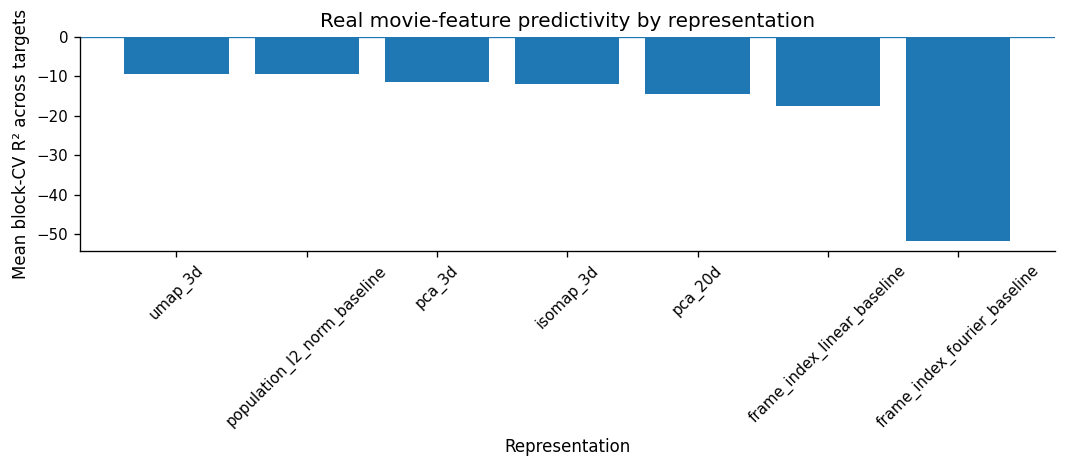

,representation,mean_r2_across_targets,mean_spearman_across_targets,n_targets
6,umap_3d,-9.277270,0.093386,5
5,population_l2_norm_baseline,-9.431165,0.004601,5
4,pca_3d,-11.514799,0.035454,5
2,isomap_3d,-11.837900,0.007714,5
3,pca_20d,-14.466426,0.102798,5
1,frame_index_linear_baseline,-17.417848,-0.152972,5
0,frame_index_fourier_baseline,-51.760036,0.123968,5


In [9]:
plot_df = latent_vs_baseline.copy()

# I aggregate over targets to obtain a compact method-level summary.
method_summary = (
    plot_df
    .groupby("representation", as_index=False)
    .agg(
        mean_r2_across_targets=("mean_r2", "mean"),
        mean_spearman_across_targets=("mean_spearman_r", "mean"),
        n_targets=("target", "nunique"),
    )
    .sort_values("mean_r2_across_targets", ascending=False)
)

save_table(
    method_summary,
    paths.tables_dir / "05_representation_method_summary.csv",
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    method_summary["representation"],
    method_summary["mean_r2_across_targets"],
)

ax.axhline(0, linewidth=0.8)
ax.set_xlabel("Representation")
ax.set_ylabel("Mean block-CV R² across targets")
ax.set_title("Real movie-feature predictivity by representation")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()

save_figure(
    fig,
    paths.figures_dir / "05_representation_feature_predictivity_summary.png",
)

plt.show()

display(method_summary)
